In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/flo_data_20k.csv')
df.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR]


In [2]:
# How big is our dataset?
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

# Column names and data types
print(df.dtypes)
print()

# Any missing values?
print("Missing values:")
print(df.isnull().sum())

Rows: 19,945
Columns: 12

master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_total_ever_online     float64
interested_in_categories_12           object
dtype: object

Missing values:
master_id                            0
order_channel                        0
last_order_channel                   0
first_order_date                     0
last_order_date                      0
last_order_date_online               0
last_order_date_offline              0
order_num_total_ever_online          0
order_num_total_ever_offline         0
customer_value_total_ever_offline    0
customer_valu

In [3]:
# Convert date columns from string to datetime
date_cols = ['first_order_date', 'last_order_date', 
             'last_order_date_online', 'last_order_date_offline']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Verify the conversion
print(df[date_cols].dtypes)
print()
print(df[date_cols].head(3))

first_order_date           datetime64[ns]
last_order_date            datetime64[ns]
last_order_date_online     datetime64[ns]
last_order_date_offline    datetime64[ns]
dtype: object

  first_order_date last_order_date last_order_date_online  \
0       2020-10-30      2021-02-26             2021-02-21   
1       2017-02-08      2021-02-16             2021-02-16   
2       2019-11-27      2020-11-27             2020-11-27   

  last_order_date_offline  
0              2021-02-26  
1              2020-01-10  
2              2019-12-01  


In [4]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
first_order_date,19945,2019-03-22 16:43:55.246929152,2013-01-14 00:00:00,2019-02-16 00:00:00,2019-08-20 00:00:00,2020-01-01 00:00:00,2021-05-27 00:00:00,NaN
last_order_date,19945,2021-01-17 12:59:57.653547264,2020-05-30 00:00:00,2020-11-11 00:00:00,2021-02-10 00:00:00,2021-04-19 00:00:00,2021-05-30 00:00:00,NaN
last_order_date_online,19945,2020-08-10 01:08:52.644773376,2014-02-24 00:00:00,2020-06-18 00:00:00,2020-12-14 00:00:00,2021-04-05 00:00:00,2021-05-30 00:00:00,NaN
last_order_date_offline,19945,2020-05-17 12:07:24.021058048,2019-01-22 00:00:00,2019-11-04 00:00:00,2020-06-22 00:00:00,2020-12-25 00:00:00,2021-05-28 00:00:00,NaN
order_num_total_ever_online,19945.0,3.110855,1.0,1.0,2.0,4.0,200.0,4.225647
order_num_total_ever_offline,19945.0,1.913913,1.0,1.0,1.0,2.0,109.0,2.06288
customer_value_total_ever_offline,19945.0,253.922597,10.0,99.99,179.98,319.97,18119.14,301.532853
customer_value_total_ever_online,19945.0,497.32169,12.99,149.98,286.46,578.44,45220.13,832.601886


In [5]:
# Outlier capping with IQR method (1st - 99th percentile)
def cap_outliers(dataframe, col):
    q1  = dataframe[col].quantile(0.01)
    q99 = dataframe[col].quantile(0.99)
    dataframe[col] = dataframe[col].clip(lower=q1, upper=q99)
    return dataframe

num_cols = ['order_num_total_ever_online', 
            'order_num_total_ever_offline',
            'customer_value_total_ever_offline', 
            'customer_value_total_ever_online']

for col in num_cols:
    df = cap_outliers(df, col)

# Check new max values
print("After capping:")
print(df[num_cols].describe().T[['min', 'mean', 'max']])

After capping:
                                     min        mean        max
order_num_total_ever_online         1.00    3.018551    20.0000
order_num_total_ever_offline        1.00    1.856054     7.0000
customer_value_total_ever_offline  19.99  246.991735  1219.9468
customer_value_total_ever_online   39.99  476.162117  3143.8104


In [6]:
# ── Feature Engineering ───────────────────────────────────

# 1. Total orders and total spend (online + offline combined)
df['total_order'] = (df['order_num_total_ever_online'] + 
                     df['order_num_total_ever_offline'])

df['total_price'] = (df['customer_value_total_ever_online'] + 
                     df['customer_value_total_ever_offline'])

# 2. Average order value
df['avg_order_value'] = df['total_price'] / df['total_order']

# 3. Online channel ratio (0 = fully offline, 1 = fully online)
df['online_ratio'] = df['order_num_total_ever_online'] / df['total_order']

# 4. Customer lifetime in days
ANALYSIS_DATE = pd.Timestamp('2021-06-01')
df['customer_lifetime_days'] = (ANALYSIS_DATE - df['first_order_date']).dt.days

# Preview
df[['total_order', 'total_price', 'avg_order_value', 
    'online_ratio', 'customer_lifetime_days']].describe().T

,count,mean,std,min,25%,50%,75%,max
total_order,19945.0,4.874605,3.563218,2.000000,3.000000,4.000000,6.000000,27.000000
total_price,19945.0,723.153853,588.868220,59.980000,339.980000,545.410000,897.780000,4363.757200
avg_order_value,19945.0,151.647456,71.000423,26.826667,104.127917,137.500769,181.632000,951.786700
online_ratio,19945.0,0.557072,0.196307,0.125000,0.428571,0.500000,0.714286,0.952381
customer_lifetime_days,19945.0,801.302833,523.396883,5.000000,517.000000,651.000000,836.000000,3060.000000


In [7]:
# ── Category Feature Engineering ─────────────────────────

# Create binary flag for each category
categories = ['KADIN', 'ERKEK', 'COCUK', 'AKTIFSPOR', 'AKTIFCOCUK', 'INDIRIM']

for cat in categories:
    df[f'cat_{cat.lower()}'] = (
        df['interested_in_categories_12']
        .str.contains(cat)
        .astype(int)
    )

# Number of distinct categories per customer
df['num_categories'] = df[[f'cat_{c.lower()}' for c in categories]].sum(axis=1)

# Check results
print("Category interest counts:")
print(df[[f'cat_{c.lower()}' for c in categories]].sum().sort_values(ascending=False))
print()
print("Avg categories per customer:", df['num_categories'].mean().round(2))

Category interest counts:
cat_aktifspor     9204
cat_kadin         7603
cat_erkek         6642
cat_cocuk         6062
cat_aktifcocuk    3437
cat_indirim          0
dtype: int64

Avg categories per customer: 1.65


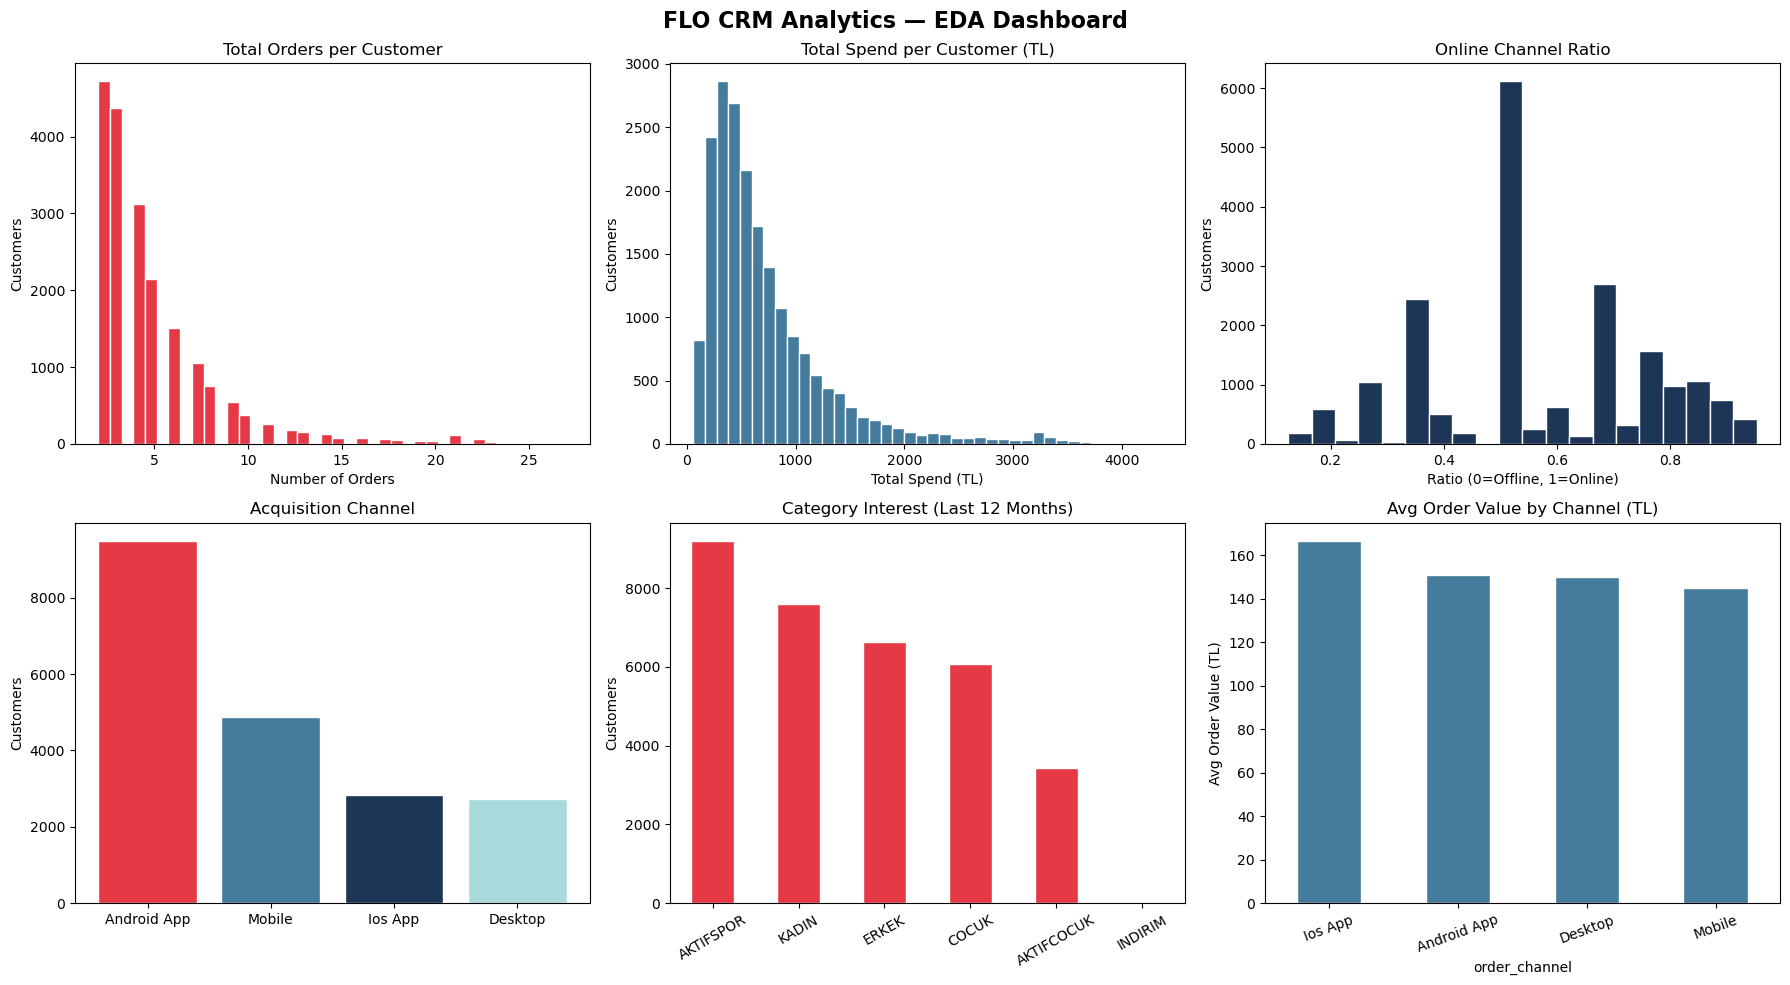

Saved → outputs/week1_eda_dashboard.png


In [8]:
# ── EDA Visualizations ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FLO CRM Analytics — EDA Dashboard', 
             fontsize=16, fontweight='bold')

COLORS = ['#E63946', '#457B9D', '#1D3557', '#A8DADC', '#F1FAEE', '#2A9D8F']

# Plot 1: Total orders distribution
axes[0,0].hist(df['total_order'], bins=40, color=COLORS[0], edgecolor='white')
axes[0,0].set_title('Total Orders per Customer')
axes[0,0].set_xlabel('Number of Orders')
axes[0,0].set_ylabel('Customers')

# Plot 2: Total spend distribution
axes[0,1].hist(df['total_price'], bins=40, color=COLORS[1], edgecolor='white')
axes[0,1].set_title('Total Spend per Customer (TL)')
axes[0,1].set_xlabel('Total Spend (TL)')
axes[0,1].set_ylabel('Customers')

# Plot 3: Online ratio distribution
axes[0,2].hist(df['online_ratio'], bins=20, color=COLORS[2], edgecolor='white')
axes[0,2].set_title('Online Channel Ratio')
axes[0,2].set_xlabel('Ratio (0=Offline, 1=Online)')
axes[0,2].set_ylabel('Customers')

# Plot 4: Order channel breakdown
channel_counts = df['order_channel'].value_counts()
axes[1,0].bar(channel_counts.index, channel_counts.values, 
              color=COLORS[:4], edgecolor='white')
axes[1,0].set_title('Acquisition Channel')
axes[1,0].set_ylabel('Customers')

# Plot 5: Category interest
cat_sums = df[[f'cat_{c.lower()}' for c in categories]].sum()
cat_sums.index = categories
cat_sums.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,1], color=COLORS[0], edgecolor='white')
axes[1,1].set_title('Category Interest (Last 12 Months)')
axes[1,1].set_ylabel('Customers')
axes[1,1].tick_params(axis='x', rotation=30)

# Plot 6: Avg order value by channel
df.groupby('order_channel')['avg_order_value'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,2], color=COLORS[1], edgecolor='white')
axes[1,2].set_title('Avg Order Value by Channel (TL)')
axes[1,2].set_ylabel('Avg Order Value (TL)')
axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../outputs/week1_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/week1_eda_dashboard.png")

In [9]:
# Save processed data for Week 2
df.to_csv('../data/flo_processed.csv', index=False)
print(f"Saved! Shape: {df.shape}")
print("Ready for Week 2: RFM + K-Means Segmentation")

Saved! Shape: (19945, 24)
Ready for Week 2: RFM + K-Means Segmentation


In [10]:
# ── Cohort Analysis ───────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/flo_master.csv')
df['first_order_date'] = pd.to_datetime(
    pd.read_csv('../data/flo_processed.csv')['first_order_date']
)

# Cohort = year of first purchase
df['cohort_year'] = df['first_order_date'].dt.year

print("Cohort distribution:")
print(df['cohort_year'].value_counts().sort_index())

Cohort distribution:
cohort_year
2013      129
2014      405
2015      614
2016      662
2017     1160
2018     1630
2019    10352
2020     4412
2021      581
Name: count, dtype: int64


In [11]:
# ── Cohort Profile ────────────────────────────────────────

cohort_profile = df.groupby('cohort_year').agg(
    num_customers=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_cltv=('cltv_6m', 'mean'),
    churn_rate=('churn', 'mean'),
    avg_lifetime_days=('customer_lifetime_days', 'mean')
).round(2)

cohort_profile['churn_rate'] = (cohort_profile['churn_rate'] * 100).round(1)
print(cohort_profile)

             num_customers  avg_monetary  avg_frequency  avg_cltv  churn_rate  \
cohort_year                                                                     
2013                   129       1286.04          10.67     78.95        37.0   
2014                   405       1002.48           7.86     74.51        42.0   
2015                   614       1033.45           7.79     86.09        38.0   
2016                   662       1075.93           7.90    105.75        37.0   
2017                  1160        998.57           7.53    118.61        38.0   
2018                  1630        874.55           6.11    136.27        40.0   
2019                 10352        685.71           4.53    153.99        33.0   
2020                  4412        573.80           3.50    195.32        29.0   
2021                   581        500.17           2.76    288.99         0.0   

             avg_lifetime_days  
cohort_year                     
2013                   2896.07  
2014     

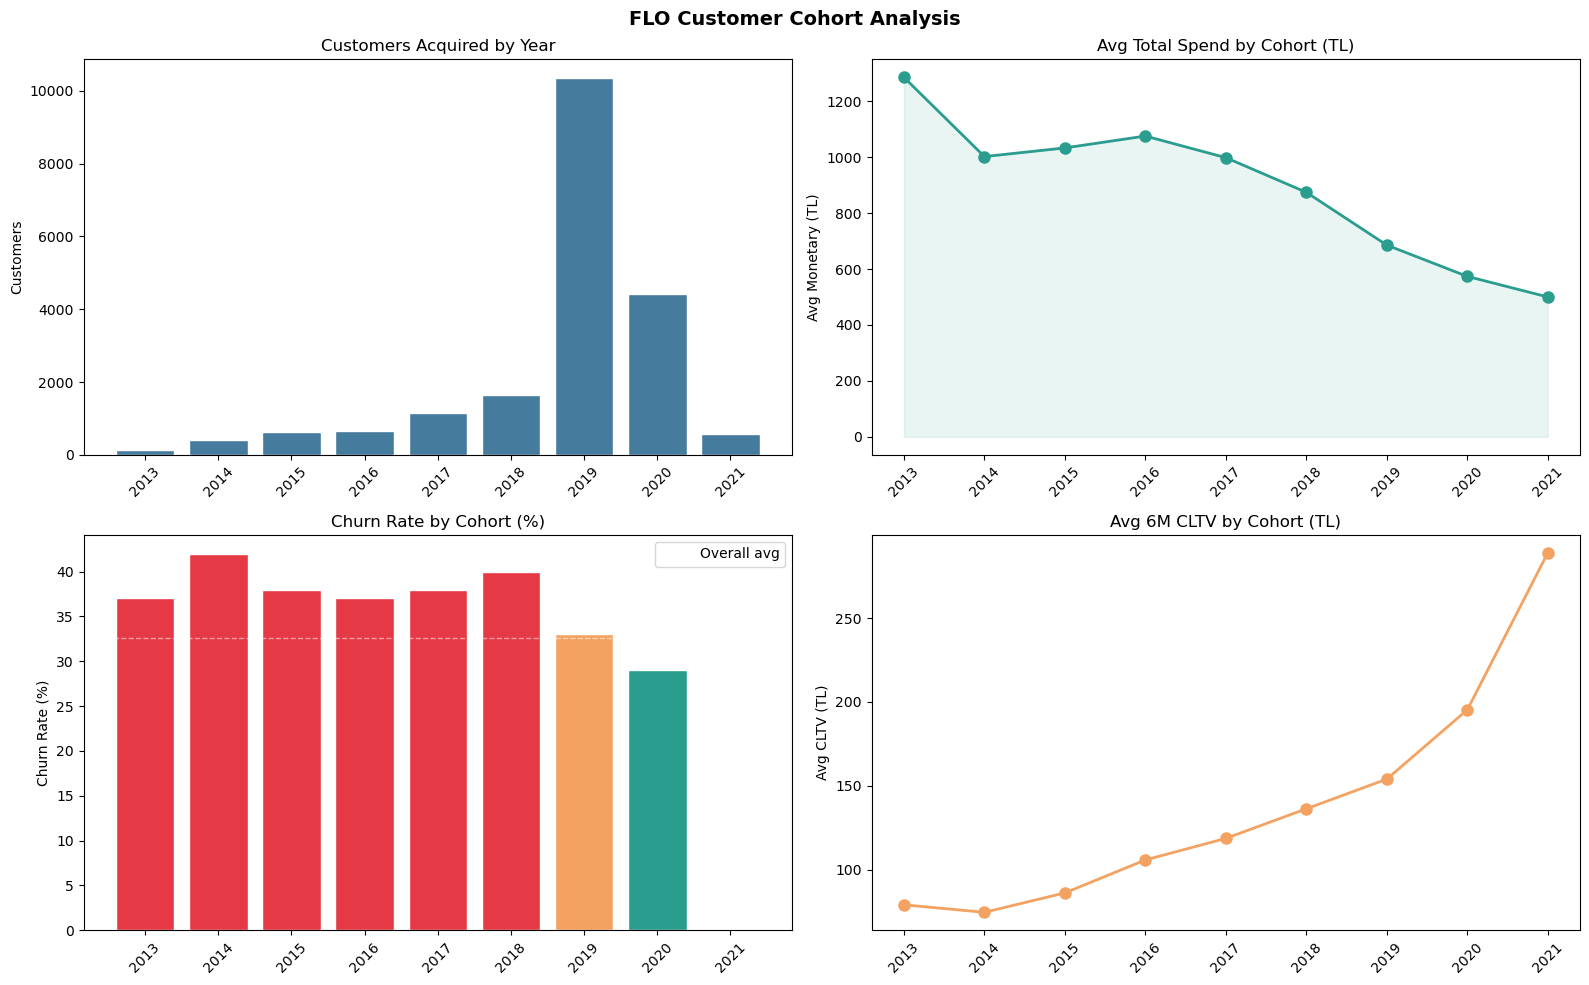

Saved!


In [12]:
# ── Cohort Visualization ──────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('FLO Customer Cohort Analysis', 
             fontsize=14, fontweight='bold')

years = cohort_profile.index.astype(str)

# Plot 1: Customer count
axes[0,0].bar(years, cohort_profile['num_customers'], 
              color='#457B9D', edgecolor='white')
axes[0,0].set_title('Customers Acquired by Year')
axes[0,0].set_ylabel('Customers')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Avg monetary by cohort
axes[0,1].plot(years, cohort_profile['avg_monetary'], 
               'o-', color='#2A9D8F', linewidth=2, markersize=8)
axes[0,1].set_title('Avg Total Spend by Cohort (TL)')
axes[0,1].set_ylabel('Avg Monetary (TL)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].fill_between(range(len(years)), 
                        cohort_profile['avg_monetary'], 
                        alpha=0.1, color='#2A9D8F')

# Plot 3: Churn rate by cohort
axes[1,0].bar(years, cohort_profile['churn_rate'],
              color=['#E63946' if x > 35 else '#F4A261' if x > 30 
                     else '#2A9D8F' for x in cohort_profile['churn_rate']],
              edgecolor='white')
axes[1,0].set_title('Churn Rate by Cohort (%)')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=32.6, color='white', linestyle='--', 
                   linewidth=1, alpha=0.5, label='Overall avg')
axes[1,0].legend()

# Plot 4: CLTV by cohort
axes[1,1].plot(years, cohort_profile['avg_cltv'],
               'o-', color='#F4A261', linewidth=2, markersize=8)
axes[1,1].set_title('Avg 6M CLTV by Cohort (TL)')
axes[1,1].set_ylabel('Avg CLTV (TL)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/week1_cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")